# Chapter 22: Building Models with DisSModel

*Part IV — DisSModel: Core and Paradigms*

## Learning Objectives

By the end of this chapter you will be able to:

- Describe the Model lifecycle's `setup()`/`execute()` hooks, plus `pre_execute()`/`post_execute()`
- Build a model one hook at a time in a notebook, then move the identical class into a runnable script
- Run a model two ways — CLI and notebook
- Understand the minimal structure of a model project
- Build a complete `ModelExecutor` around a real model, end to end


In [1]:
# Standard imports — add chapter-specific imports below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Chapter 21 got `dissmodel` and its extension packages installed, then ran two of DisSModel's own example models without explaining either. This chapter opens the hood: the lifecycle those models share, built up one hook at a time; the same model as a standalone script; and, further down, how a model actually gets packaged, run for real, and made reproducible.


## The Model Lifecycle

Every DisSModel model, regardless of what it simulates, descends from a common `Model` base class. Only two hooks matter to start:

| Hook | Called | Purpose |
|---|---|---|
| `setup(**kwargs)` | once, right after construction | one-time setup — build a neighborhood, initialize state |
| `execute()` | once per tick | the transition rule itself — the only required override |

The fastest way to make that table concrete is to build the smallest possible model, one hook at a time, the same way DisSModel's own tutorial notebooks do — a few cells, each adding one piece, rather than one finished class dropped in all at once.

**Step 1 — a substrate, and nothing else.** Every model needs something to hold its state. A `vector_grid()`, exactly like Chapter 7's `GeoDataFrame`-as-grid, is the smallest substrate available:

In [2]:
from dissmodel.core import Model, Environment
from dissmodel.geo import vector_grid

gdf = vector_grid(dimension=(3, 3), resolution=1, attrs={"age": 0})
gdf[["age"]]

,age
id,
0-0,0
1-0,0
2-0,0
0-1,0
1-1,0
2-1,0
0-2,0
1-2,0
2-2,0


**Step 2 — an `Environment`, then `setup()` and nothing else.** A `Model` needs an active `Environment` to register itself with the moment it's constructed — even one that never gets `run()` yet. Build that `Environment` first, then a minimal `Model` subclass that only overrides `setup()`: it fires once, at construction time, and does exactly one thing here — store whatever it was constructed with.

In [3]:
env = Environment(start_time=0, end_time=3)

class Ticker(Model):
    def setup(self, gdf):
        self.gdf = gdf

ticker = Ticker(gdf=gdf)
print("Constructed. age is still:", ticker.gdf["age"].tolist())

Constructed. age is still: [0, 0, 0, 0, 0, 0, 0, 0, 0]


**Step 3 — add `execute()`.** This is the hook that actually runs every tick. Here, it does the simplest possible thing: add one to every cell's `age`:

In [4]:
class Ticker(Model):
    def setup(self, gdf):
        self.gdf = gdf

    def execute(self):
        self.gdf["age"] = self.gdf["age"] + 1

**Step 4 — construct an `Environment`, then run.** Notice `ticker` below is never explicitly handed to `env` — construction alone was enough to register it, exactly as the lifecycle table promised:

In [5]:
gdf = vector_grid(dimension=(3, 3), resolution=1, attrs={"age": 0})

env = Environment(start_time=0, end_time=3)
ticker = Ticker(gdf=gdf)

print("Before run:", gdf["age"].tolist())
env.run()
print("After run: ", gdf["age"].tolist())

Before run: [0, 0, 0, 0, 0, 0, 0, 0, 0]
Running from 0 to 3 (duration: 3)
After run:  [4, 4, 4, 4, 4, 4, 4, 4, 4]


<div class="admonition warning">
<p class="admonition-title">Watch out</p>
<p><code>age</code> ends at <strong>4</strong>, not 3 — <code>end_time=3</code> with <code>start_time=0</code> runs ticks at 0, 1, 2, <em>and</em> 3, four ticks in total, not three. <code>end_time</code> is inclusive. This is exactly the kind of off-by-one that's worth confirming with a print statement the first time you use a new <code>Environment</code>, not assuming.</p>
</div>

## The Same Model, as a Script

Every cell above ran in this notebook — fine for building intuition one hook at a time, but not how a model actually gets run in practice. A real model lives in its own `.py` file, callable from a terminal, following the same minimal pattern every example in the DisSModel ecosystem uses: build a substrate, construct an `Environment` and the model, call `env.run()`.

```python
# ticker_model.py
from dissmodel.core import Model, Environment
from dissmodel.geo import vector_grid


class Ticker(Model):
    def setup(self, gdf):
        self.gdf = gdf

    def execute(self):
        self.gdf["age"] = self.gdf["age"] + 1


if __name__ == "__main__":
    gdf = vector_grid(dimension=(3, 3), resolution=1, attrs={"age": 0})
    env = Environment(start_time=0, end_time=3)
    ticker = Ticker(gdf=gdf)

    env.run()
    print(gdf["age"].tolist())
```

```bash
python ticker_model.py
```

Nothing about `Ticker` changed — only where it lives, and the `if __name__ == "__main__":` guard Chapter 5 already introduced, keeping the "build it and run it" part separate from the class definition so another script could `import Ticker` without triggering a run. *Running a First Model*, below, uses this exact script shape as the starting point for a real fire-spread model; *The Reproducible Way*, later in this chapter, layers `ModelExecutor` on top of it.

`setup` and `execute` are enough to build with. `Model` also exposes `pre_execute()` and `post_execute()` — called once per tick, immediately before and after `execute()` — for a snapshot-before or cleanup-after step that doesn't belong inside the transition rule itself. Neither shows up again until a model genuinely needs one; `Ticker` didn't, and most models don't either.

## Substrates, Briefly

One more thing worth knowing before *Running a First Model*, below: a `Model`'s state is deliberately not tied to one data structure. A `SpatialModel` keeps its state in `self.gdf`, a `GeoDataFrame` exactly like the ones Chapter 7 built; a `RasterModel` keeps its state in `self.backend`, wrapping NumPy arrays exactly like Chapter 8's elevation grid. Both extend the same `Model` lifecycle from above — `setup`, `execute`, and the rest work identically either way.

This isn't a foundational design principle so much as a practical convenience DisSModel makes available: some processes fit a `GeoDataFrame`'s exact geometry more naturally (Chapter 7's substrate-choice guidance still applies directly), others fit a regular raster grid better, and a few — Chapter 27's coastal case study among them — are worth implementing on both, as a correctness check against each other. Chapter 24 picks this distinction back up properly, once there's a real cellular automaton to run on either substrate.

## Running a First Model

`dissmodel-ca` ships the same Game of Life model — the `GameOfLife` class Chapter 24 returns to in depth — in two runnable forms built on the identical class: a plain CLI script, and a didactic notebook. (The package also ships an optional Streamlit dashboard — worth a look once Chapter 24 gets to CA models in depth, not needed here.)

**CLI** (`examples/cli/ca_game_of_life.py`) is the fastest way to confirm a model runs at all — a linear script, no framework beyond `dissmodel` itself:

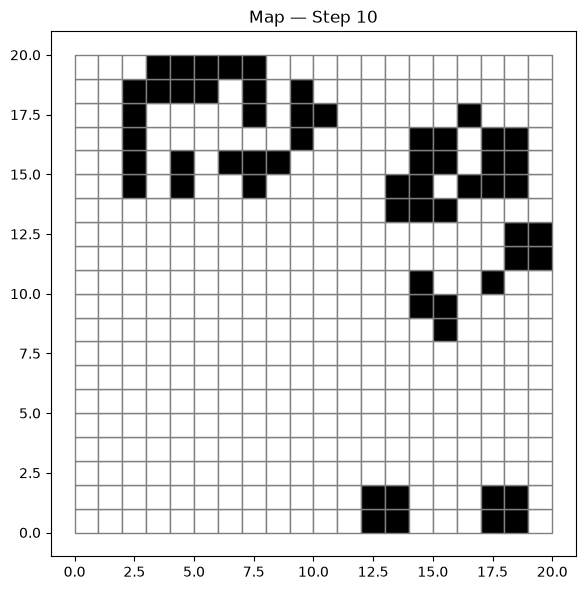

Final alive cells: 59


In [6]:
from dissmodel.core import Environment
from dissmodel.geo import vector_grid
from dissmodel_ca.models import GameOfLife
from dissmodel.visualization import Map
from matplotlib.colors import ListedColormap

gdf = vector_grid(dimension=(20, 20), resolution=1, attrs={"state": 0}, crs="EPSG:31983")
env = Environment(start_time=0, end_time=10)
gol = GameOfLife(gdf=gdf)
gol.initialize()  # seeds the starting alive/dead pattern

cmap = ListedColormap(["white", "black"])
Map(gdf=gdf, plot_params={"column": "state", "cmap": cmap, "ec": "gray"})

env.run()
print("Final alive cells:", int(gdf["state"].sum()))

As a standalone file, this same script runs from a terminal exactly like `ticker_model.py` above:

```bash
python examples/cli/ca_game_of_life.py
```

**Notebooks** (`examples/notebooks/`) are the didactic entry point — the package's own README calls them "the best way to learn about each model," and `ca_game_of_life.ipynb` specifically walks through Conway's rule table and a library of seed patterns (`blinker`, `glider`, `pulsar`, and others) independently of the `GameOfLife` class itself.

## Minimal Project Structure

The CLI/notebook split above is not incidental — it's a convention every package in the DisSModel ecosystem follows:

```
dissmodel-ca/
  src/dissmodel_ca/models/     # the "science" layer — model classes only
  examples/
    cli/                       # fastest possible confirmation that a model runs
    notebooks/                 # didactic, step-by-step walkthroughs
```

`src/<package>/models/` holds only model classes — subclasses of `CellularAutomaton`, `SpatialModel`, or `RasterModel`, with no CLI parsing, no argparse, no I/O — exactly the "no I/O in the science layer" principle *The Reproducible Way*, below, puts into practice. `examples/` is where that separation pays off: two ways to *use* a model, neither of which requires touching the model's own source. (A package may add its own extras alongside these two — `dissmodel-ca`'s `examples/streamlit/`, revisited in Chapter 24, is one.)

## The Reproducible Way: ModelExecutor

The Game of Life script above is the fastest way to confirm a model runs — but it isn't reproducible: no input file is recorded, no output is saved, no checksum proves the result came from that exact input. Chapter 21 introduced the `ModelExecutor` contract (`validate → load → run → save`) in the abstract; here it is filled in, end to end, for `dissmodel-ca`'s `FireModel`:

In [7]:
from dissmodel.executor import ExperimentRecord, ModelExecutor, DataSource
from dissmodel.io import load_dataset, save_dataset


class ForestFireExecutor(ModelExecutor):
    name = "forest_fire"

    def load(self, record: ExperimentRecord):
        gdf, checksum = load_dataset(record.source.uri)
        record.source.checksum = checksum
        return gdf

    def run(self, data, record: ExperimentRecord):
        from dissmodel.core import Environment
        from dissmodel_ca.models import FireModel

        env = Environment(start_time=0, end_time=record.parameters.get("end_time", 20))
        model = FireModel(
            gdf=data,
            initial_fire_density=record.parameters.get("initial_fire_density", 0.05),
            seed=record.parameters.get("seed", 42),
        )
        model.initialize()  # seed the starting fires: setup() alone leaves every cell FOREST
        env.run()
        return data

    def save(self, result, record: ExperimentRecord) -> ExperimentRecord:
        uri = record.output_path or "output.gpkg"
        output_checksum = save_dataset(result, uri)
        record.output_path = uri
        record.output_sha256 = output_checksum
        record.status = "completed"
        return record

Unlike the CLI script above, a `ModelExecutor` doesn't start from an in-memory `vector_grid()` — `load()` reads from `record.source.uri`, so there needs to be an actual file on disk first. Generate one the same way the `vector_grid()` calls above did, then save it:

In [8]:
from dissmodel.geo import vector_grid
from dissmodel.io import save_dataset

gdf = vector_grid(dimension=(15, 15), resolution=1, attrs={"state": 0}, crs="EPSG:31983")
save_dataset(gdf, "forest.gpkg")
print("Sample input written.")

Sample input written.


With an input file in hand, build an `ExperimentRecord` — the object every phase of the executor reads from and writes back to — and run all three phases in sequence:

In [9]:
record = ExperimentRecord(
    experiment_id="fire_demo_001",
    model_name="forest_fire",
    source=DataSource(type="file", uri="forest.gpkg"),
    parameters={"initial_fire_density": 0.1, "seed": 7, "end_time": 10},
)

executor = ForestFireExecutor()
data = executor.load(record)
result = executor.run(data, record)
record = executor.save(result, record)

print("Status:", record.status)
print("Output path:", record.output_path)
print("Source checksum: ", record.source.checksum[:16], "...")
print("Output checksum: ", record.output_sha256[:16], "...")
print("Final cell states:", result["state"].value_counts().to_dict())  # 0 forest, 1 burning, 2 burned

Running from 0 to 10 (duration: 10)


Status: completed
Output path: output.gpkg
Source checksum:  baf1ecd4eba96605 ...
Output checksum:  d4b434ae246dccd8 ...
Final cell states: {2: 225}


Compare this to the plain CLI script from *Running a First Model*: `load()`/`save()` do the I/O the CLI script never bothered with, computing a checksum on the way in and on the way out — provenance that survives independent of anyone's memory of what ran. `run()` stays exactly as free of I/O as Chapter 21 argued it should — it receives already-loaded data, returns a result, and never once touches a filesystem path directly.

The command-line entry point comes almost for free. Add a `run_cli` call at the bottom of the same file, and the executor gains a terminal interface without writing any argument-parsing code by hand:

```python
# forest_fire_executor.py — same ForestFireExecutor class, plus:
if __name__ == "__main__":
    from dissmodel.executor.cli import run_cli
    run_cli(ForestFireExecutor)
```

```bash
python forest_fire_executor.py run --input forest.gpkg --param initial_fire_density=0.1 --param seed=7
```

The `--param` flags on the command line land directly in `record.parameters` — the same dictionary `run()` already reads `initial_fire_density`, `seed`, and `end_time` from above. (One honest caveat: `output_sha256` isn't a field `ExperimentRecord` declares in its schema — it works as a plain Python attribute, and, more importantly, it's the exact name Chapter 28's test harness checks for, which matters more here than schema purity does.)

## When to Use Which Pattern

Two patterns, two different jobs — not a beginner version and an advanced version of the same thing:

- **The `vector_grid()` + `Environment` + model + `env.run()` pattern** (*Running a First Model*) is for exploring a model interactively: a notebook cell, a Streamlit app, a quick sanity check. Nothing about it is saved or checksummed, and that's fine — that isn't what it's for.
- **The `ModelExecutor` pattern** (this section) is for anything that needs to be run again later and trusted: a batch of experiments, a result cited in a paper, a job submitted to the platform Chapter 29 introduces. `disslucc-continuous`, `disslucc-discrete`, and `brmangue-dissmodel` — Chapters 26 and 27's domain models — are built entirely on this second pattern; `ForestFireExecutor` here is the same contract wrapped around the smallest model that makes it concrete.

## Exercises

1. **Trace the lifecycle.** For a hypothetical model that runs for 5 ticks, list every lifecycle hook call in order, from construction through the end of `env.run()` — including `pre_execute()`/`post_execute()` if the model overrides them.
2. **A second tick counter.** Build a `Ticker`-style model from scratch, one hook at a time as above, but tracking a `count` attribute on the model itself (not the `GeoDataFrame`) instead of a per-cell `age`.
3. **Confirm your install.** Using the `dissmodel`/`dissmodel-ca` install from Chapter 21, run the *Running a First Model* CLI cell and confirm the Game of Life pattern evolves over 10 steps.
4. **A second parameter.** Modify `ForestFireExecutor.run()` so a new parameter, `wind_direction`, is read from `record.parameters` (even if `FireModel` itself ignores it for now). Confirm it round-trips correctly by printing `record.parameters` after construction.
5. **Break the checksum, on purpose.** After running the full `ForestFireExecutor` example, open `forest.gpkg` in a text or GIS editor, change one value, save it, and reload it with `load_dataset()`. Does `record.source.checksum` change? What would that tell a collaborator re-running your experiment later?
6. **CLI vs ModelExecutor, in your own words.** Without looking back at *When to Use Which Pattern*, write two sentences: one describing when you'd reach for the plain CLI pattern, one for `ModelExecutor`. Compare against the section afterward.


In [10]:
# Your code here

## Summary

### Key concepts introduced

- The `Model` lifecycle's core hooks, `setup()` and `execute()`, built up one at a time against a minimal `Ticker` model — plus `pre_execute()`/`post_execute()` for the cases that need them
- The same model, unchanged, as a standalone `.py` script instead of notebook cells
- Two ways to run a packaged model — CLI (fastest confirmation) and notebooks (didactic) — driving identical model classes
- The `src/<package>/models/` (science) versus `examples/` (usage) split as the minimal shape of a DisSModel project
- A complete `ModelExecutor`, `ForestFireExecutor`, built and run end to end — `load()` and `save()` carrying real, verified checksums, `run()` staying free of I/O
- `run_cli()` turning any `ModelExecutor` into a command-line tool without hand-written argument parsing

Chapters 23 through 25 return to this same `Model`/`ModelExecutor` foundation for each simulation paradigm in turn — system dynamics, cellular automata in depth (including `dissmodel-ca`'s Streamlit dashboard), and agent-based modeling.


## Further Reading

- dissmodel-ca on GitHub, including its README on the didactic notebooks: <https://github.com/DisSModel/dissmodel-ca>
- DisSModel documentation and API reference: <https://dissmodel.github.io/dissmodel/>
